# 09. キャップストーン — 1つの系を3つのレンズで

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 1つの2次系を ODE/ラプラス・畳み込み・極の3視点で解き、同じ $y(t)$ に到達することを確かめる。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture — 1つの系を3つのレンズで

これまでの道具を1つの系で束ねる。質量-バネ-ダンパ(ステップ強制・初期静止)

$$ \ddot y + 3\dot y + 2y = 2\,u(t), \qquad y(0)=\dot y(0)=0 $$

を、(1) ODE をラプラスで解く、(2) インパルス応答と畳み込み、(3) 極と安定性、の3レンズで見る。
**3つとも同じ $y(t)$** に行き着くことを確かめる。

## 2. Lens 1 — ODE をラプラスで代数化

微分則で $s$ 領域へ移すと $Y(s)=\dfrac{2}{s(s^2+3s+2)}=\dfrac{2}{s(s+1)(s+2)}$。部分分数 → 逆変換。

In [2]:
Y = 2 / (s * (s + 1) * (s + 2))
display(partial_fractions(Y))          # 1/s - 2/(s+1) + 1/(s+2)
y1 = sp.simplify(Linv(Y))
display(y1)                            # 1 - 2 e^{-t} + e^{-2t}

## 3. Lens 2 — インパルス応答と畳み込み

伝達関数 $H(s)=\dfrac{2}{s^2+3s+2}$、インパルス応答 $h=\mathcal{L}^{-1}\{H\}=2(e^{-t}-e^{-2t})$。
ステップ応答は $h$ とステップの畳み込み。Lens 1 と一致するはず。

In [3]:
dt = 0.005
tt = np.arange(0, 12, dt)
H = systems.tf([2.0], [1.0, 3.0, 2.0])                  # 2 / (s^2 + 3s + 2)
h = systems.impulse_response(H, tt)                     # 2(e^{-t} - e^{-2t})
step_conv = systems.convolve(h, np.ones_like(tt), dt)   # h * u
step_lsim = systems.step_response(H, tt)
y1fun = transforms.as_function(y1)
print("Lens1 (Laplace) vs Lens2 (h*u)  max err:", np.max(np.abs(y1fun(tt) - step_conv)))
print("Lens2  lsim     vs Lens2 (h*u)  max err:", np.max(np.abs(step_lsim - step_conv)))

Lens1 (Laplace) vs Lens2 (h*u)  max err: 0.0012458275105479422
Lens2  lsim     vs Lens2 (h*u)  max err: 0.0012458275105479422


## 4. Lens 3 — 極と安定性(過渡 + 定常)

$H$ の極は $-1,-2$(ともに左半面 → 安定)。応答は **過渡**(極由来、$e^{-t},e^{-2t}$ で消える)と
**定常**(入力の極 $s=0$ 由来、DC ゲイン $=1$)の和。

In [4]:
print("poles:", systems.poles(H), "->", systems.classify_stability(H))
print("steady-state value (DC gain):", systems.dc_gain(H))
print("transient part  y(t) - 1 =", sp.simplify(y1 - 1))   # -2 e^{-t} + e^{-2t} -> 0

poles: [-2. -1.] -> stable
steady-state value (DC gain): 1.0
transient part  y(t) - 1 = (1 - 2*exp(t))*exp(-2*t)


## 5. 3つのレンズ、ひとつの答え

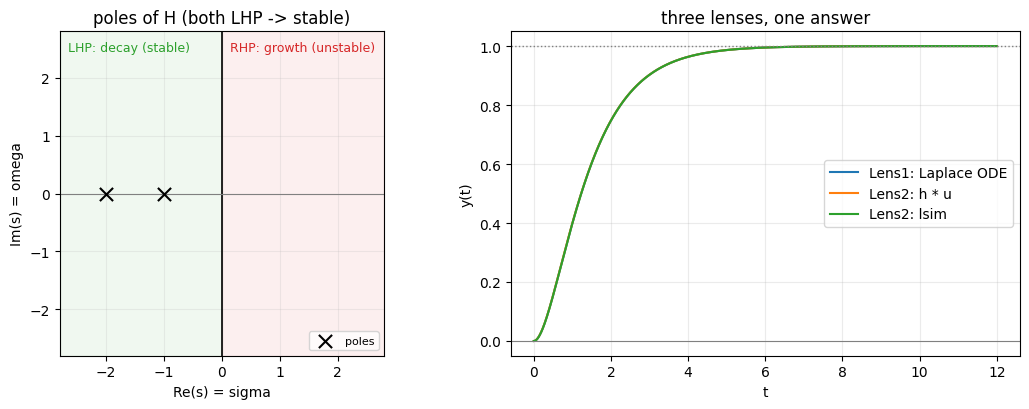

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plotting.plot_s_plane(poles=systems.poles(H), ax=axes[0], title="poles of H (both LHP -> stable)")
plotting.plot_time_responses(
    tt, [y1fun(tt), step_conv, step_lsim],
    labels=["Lens1: Laplace ODE", "Lens2: h * u", "Lens2: lsim"],
    ax=axes[1], title="three lenses, one answer", ylabel="y(t)")
axes[1].axhline(1.0, color="gray", ls=":", lw=1)
plt.tight_layout()

## 6. 何が違うのか — レンズごとの問い

| レンズ | 答える問い | 道具(章) |
|---|---|---|
| ODE/ラプラス | 解の **時間の式** は? | 微分則・部分分数・逆変換(02–04) |
| 畳み込み/インパルス応答 | 任意入力への **応答** は? | $h$, $Y=HX$(05) |
| 極・安定性 | **形・安定性・速さ** は? | 極の位置(06) |

同じ $y(t)=1-2e^{-t}+e^{-2t}$ を3つの角度から読んだ。これがラプラス変換の統一力。

## 7. Exercises / Advanced

- **Basic**: 同じ系を $y(0)=1,\ \dot y(0)=0$ で解き直し、零入力応答が加わることを3レンズで確認せよ。
- **Applied**: ダンピングを $3\to1$ に下げ(underdamped)、極が複素になり応答が振動することを示せ。
- **Advanced**: 入力を $u(t)=\sin\omega t$ にし、定常応答の振幅が $|H(i\omega)|$ で決まることを確かめよ。